In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import os

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')





# ============================================================
# This cell imports all the required libraries, initializes
# the random seeds for reproducibility, detects the available
# computing device (CPU or GPU), and prints the PyTorch version
# along with the selected device.
# ============================================================




# ============================================================
# Detailed Explanation:
#
# - Imports PyTorch modules for building, training, and optimizing
#   neural networks.
# - Imports TorchVision utilities for working with image datasets
#   and applying data transformations.
# - Imports DataLoader to efficiently load and batch the dataset
#   during training and testing.
# - Imports NumPy for numerical computations, Matplotlib for
#   plotting graphs and images, SciPy for statistical analysis,
#   and OS for interacting with the operating system if needed.
#
# - Sets the random seeds for both PyTorch and NumPy to ensure
#   reproducible results. This means that random operations such
#   as weight initialization or random sampling will produce the
#   same output each time the notebook is executed.
#
# - Detects whether a CUDA-enabled GPU is available. If a GPU is
#   found, computations are performed on the GPU for faster
#   training; otherwise, the CPU is used.
#
# - Finally, prints the installed PyTorch version and the device
#   being used, allowing you to verify the execution environment.
#
# Example:
# If CUDA is available, the output may be:
#   PyTorch version : 2.x.x
#   Device          : cuda
#
# Otherwise, it will display:
#   Device          : cpu
# ============================================================

PyTorch version : 2.11.0+cu128
Device          : cuda


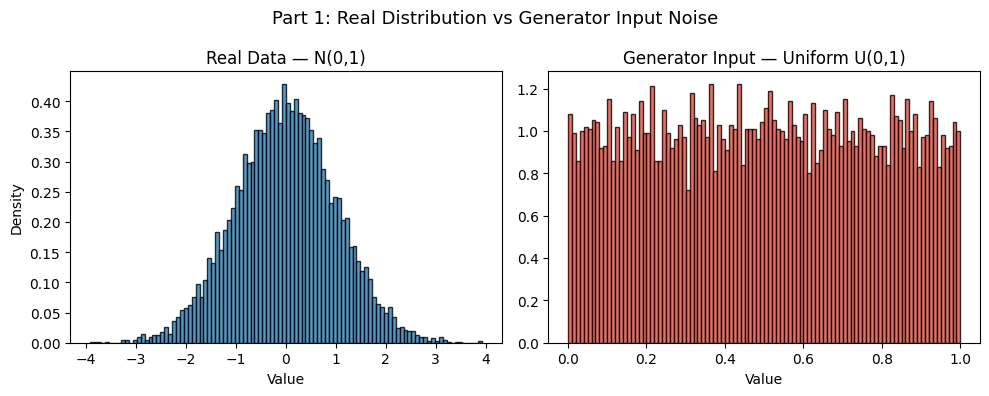

Goal: Train generator to transform red (uniform) → blue (gaussian)
Real data  — mean: -0.0021  std: 1.0034
Noise data — mean: 0.5001  std: 0.2884


In [2]:
# ── PART 1: 1D Gaussian GAN ───────────────────────────────────────────────
#
# Goal: Train a generator to produce 1D values that follow N(0,1)
# starting from uniform noise U(0,1)
#
# Why this exercise?
# Before tackling image generation, this toy example builds intuition:
# - Generator: takes random noise → outputs a number
# - Discriminator: takes a number → decides real (from N(0,1)) or fake
# - Together they play a minimax game until generator fools discriminator
#
# If the generator succeeds, its output distribution should match N(0,1)
# We verify this by comparing statistical moments

def generate_real_data(n_samples=10000, n_dim=1):
    """Real data: samples from standard normal N(0,1)"""
    return np.random.randn(n_samples, n_dim).astype(np.float32)

def generate_noise(n_samples, noise_dim=10):
    """Noise: samples from uniform U(0,1) — generator input"""
    return np.random.rand(n_samples, noise_dim).astype(np.float32)

# Visualize real data distribution
real_data = generate_real_data(10000)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(real_data, bins=100, color='#2980b9',
         edgecolor='black', alpha=0.8, density=True)
plt.title('Real Data — N(0,1)', fontsize=12)
plt.xlabel('Value')
plt.ylabel('Density')

plt.subplot(1, 2, 2)
noise = generate_noise(10000)
plt.hist(noise[:, 0], bins=100, color='#e74c3c',
         edgecolor='black', alpha=0.8, density=True)
plt.title('Generator Input — Uniform U(0,1)', fontsize=12)
plt.xlabel('Value')

plt.suptitle('Part 1: Real Distribution vs Generator Input Noise',
             fontsize=13)
plt.tight_layout()
plt.show()

print('Goal: Train generator to transform red (uniform) → blue (gaussian)')
print(f'Real data  — mean: {real_data.mean():.4f}  std: {real_data.std():.4f}')
print(f'Noise data — mean: {noise.mean():.4f}  std: {noise.std():.4f}')








# ============================================================
# This cell prepares the dataset for a simple 1D GAN experiment
# by generating real Gaussian-distributed data and random
# uniform noise. It then visualizes both distributions and
# compares their statistical properties to establish the
# generator's learning objective.
# ============================================================





# ============================================================
# Detailed Explanation:
#
# - This experiment introduces the core idea behind Generative
#   Adversarial Networks (GANs) using a simple one-dimensional
#   problem instead of complex images.
#
# - The function generate_real_data() creates samples from a
#   standard normal (Gaussian) distribution N(0,1). These values
#   represent the "real" data that the discriminator will learn
#   to recognize.
#
# - The function generate_noise() generates random values from a
#   uniform distribution U(0,1). These random values act as the
#   generator's input (latent noise). Initially, this noise has
#   no resemblance to the real Gaussian distribution.
#
# - A histogram of the real Gaussian samples is plotted to show
#   the bell-shaped distribution centered around zero.
#
# - A second histogram visualizes the uniform noise supplied to
#   the generator, illustrating that its values are evenly spread
#   between 0 and 1.
#
# - Comparing these two plots highlights the generator's task:
#   learn a transformation that converts uniformly distributed
#   random noise into samples that closely follow the Gaussian
#   distribution.
#
# - Finally, the code prints the mean and standard deviation of
#   both datasets. The real data should have statistics close to
#   mean = 0 and standard deviation = 1, while the uniform noise
#   has noticeably different statistics. During training, the
#   generator aims to produce outputs whose statistics become
#   increasingly similar to those of the real data.
#
# Example:
# Real Data (N(0,1)):
#     Mean ≈ 0.00
#     Std  ≈ 1.00
#
# Generator Input (U(0,1)):
#     Mean ≈ 0.50
#     Std  ≈ 0.29
#
# The GAN's objective is to transform samples with the second
# set of statistics into samples that resemble the first.
# ============================================================

In [3]:
# ── 1D Generator ──────────────────────────────────────────────────────────
# Input:  10-dimensional uniform noise
# Output: 1-dimensional value (should look like N(0,1) after training)
# Tanh activation in output — allows negative values like a real Gaussian

class Generator1D(nn.Module):
    def __init__(self, noise_dim=10, hidden_dim=64, n_layers=1):
        super(Generator1D, self).__init__()

        layers = []
        in_dim = noise_dim

        for _ in range(n_layers):
            layers += [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
            in_dim  = hidden_dim

        layers.append(nn.Linear(in_dim, 1))  # output 1 value
        layers.append(nn.Tanh())             # output in (-1, 1)

        self.network = nn.Sequential(*layers)

    def forward(self, z):
        return self.network(z)


# ── 1D Discriminator ──────────────────────────────────────────────────────
# Input:  1-dimensional value
# Output: probability that input is REAL (from N(0,1))
# Sigmoid output → probability in (0,1)

class Discriminator1D(nn.Module):
    def __init__(self, hidden_dim=64, n_layers=1):
        super(Discriminator1D, self).__init__()

        layers = []
        in_dim = 1

        for _ in range(n_layers):
            layers += [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
            in_dim  = hidden_dim

        layers.append(nn.Linear(in_dim, 1))   # output 1 score
        layers.append(nn.Sigmoid())            # probability in (0,1)

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Instantiate
NOISE_DIM = 10
G_LAYERS  = 1
D_LAYERS  = 1

G_1d = Generator1D(noise_dim=NOISE_DIM, hidden_dim=64,
                   n_layers=G_LAYERS).to(device)
D_1d = Discriminator1D(hidden_dim=64,
                       n_layers=D_LAYERS).to(device)

print('Generator:')
print(G_1d)
print(f'\nDiscriminator:')
print(D_1d)

g_params = sum(p.numel() for p in G_1d.parameters())
d_params = sum(p.numel() for p in D_1d.parameters())
print(f'\nGenerator parameters     : {g_params:,}')
print(f'Discriminator parameters : {d_params:,}')






# ============================================================
# This cell defines the Generator and Discriminator neural
# networks for the 1D GAN experiment, creates their instances,
# and displays their architectures along with the total number
# of trainable parameters.
# ============================================================





# ============================================================
# Detailed Explanation:
#
# - The Generator1D model is responsible for transforming a
#   10-dimensional random noise vector into a single numerical
#   value that should eventually resemble a sample drawn from
#   the real Gaussian distribution N(0,1).
#
# - The generator is built using one or more fully connected
#   (Linear) layers followed by Tanh activation functions. The
#   number of hidden layers can be adjusted using the n_layers
#   parameter, making the architecture flexible.
#
# - The final Linear layer reduces the hidden representation to
#   a single output value, and a final Tanh activation constrains
#   the output to the range (-1, 1), allowing both positive and
#   negative values similar to a Gaussian distribution.
#
# - The Discriminator1D model acts as a binary classifier. It
#   receives a single value (either a real Gaussian sample or a
#   fake sample generated by the generator) and predicts the
#   probability that the input is real.
#
# - Like the generator, the discriminator is composed of Linear
#   layers with Tanh activations. Its final layer uses a Sigmoid
#   activation to produce a probability between 0 and 1:
#       • Output close to 1 → likely a real sample.
#       • Output close to 0 → likely a generated (fake) sample.
#
# - After defining both classes, the code instantiates the
#   generator and discriminator using the chosen hyperparameters
#   (noise dimension, hidden size, and number of layers) and
#   moves them to the selected computation device (CPU or GPU).
#
# - Finally, the architectures are printed, and the total number
#   of trainable parameters in each network is calculated. This
#   provides an overview of each model's complexity before
#   training begins.
#
# Example:
# Random Noise (10 values)
#          │
#          ▼
#      Generator
#          │
#          ▼
#     Generated Value (e.g., 0.42)
#          │
#          ├──────────────┐
#          ▼              ▼
#     Discriminator   Real Sample
#          │              │
#          └──────┬───────┘
#                 ▼
#     Probability of being REAL
# ============================================================

Generator:
Generator1D(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): Tanh()
  )
)

Discriminator:
Discriminator1D(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

Generator parameters     : 769
Discriminator parameters : 193


In [4]:
def train_gan_1d(generator, discriminator, epochs=1000,
                 batch_size=128, noise_dim=10):

    criterion   = nn.BCELoss()
    g_optimizer = optim.Adam(generator.parameters(),     lr=1e-3)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=1e-3)

    g_losses = []
    d_losses = []

    # Real and fake labels
    # Label smoothing: real=0.9 instead of 1.0
    # Prevents discriminator from becoming overconfident
    real_label = 0.9
    fake_label = 0.0

    print(f'Training 1D GAN for {epochs} epochs...')
    print(f'{"Epoch":>8}  {"D Loss":>10}  {"G Loss":>10}')
    print('-' * 35)

    for epoch in range(epochs):

        # ── Step 1: Train Discriminator ───────────────────────────────────
        # Goal: correctly classify real as real and fake as fake
        # D should output ~0.9 for real, ~0.0 for fake

        discriminator.zero_grad()

        # Real data batch
        real_data  = torch.FloatTensor(
            np.random.randn(batch_size, 1)).to(device)
        real_labels = torch.full((batch_size, 1),
                                  real_label).to(device)
        d_real_out  = discriminator(real_data)
        d_real_loss = criterion(d_real_out, real_labels)

        # Fake data batch — generator output
        noise      = torch.FloatTensor(
            np.random.rand(batch_size, noise_dim)).to(device)
        fake_data  = generator(noise).detach()  # detach: don't backprop into G
        fake_labels= torch.full((batch_size, 1),
                                  fake_label).to(device)
        d_fake_out  = discriminator(fake_data)
        d_fake_loss = criterion(d_fake_out, fake_labels)

        # Total discriminator loss
        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # ── Step 2: Train Generator ───────────────────────────────────────
        # Goal: fool the discriminator — make it output ~1.0 for fake data
        # Generator wants discriminator to think its output is REAL

        generator.zero_grad()

        noise     = torch.FloatTensor(
            np.random.rand(batch_size, noise_dim)).to(device)
        fake_data = generator(noise)

        # Generator loss: discriminator should output 1.0 (real) for fake data
        g_out  = discriminator(fake_data)
        g_loss = criterion(g_out,
                           torch.ones(batch_size, 1).to(device))
        g_loss.backward()
        g_optimizer.step()

        g_losses.append(g_loss.item())
        d_losses.append(d_loss.item())

        if (epoch + 1) % 100 == 0:
            print(f'{epoch+1:>8}  {d_loss.item():>10.4f}'
                  f'  {g_loss.item():>10.4f}')

    return g_losses, d_losses


g_losses_1d, d_losses_1d = train_gan_1d(
    generator     = G_1d,
    discriminator = D_1d,
    epochs        = 1000,
    batch_size    = 128,
    noise_dim     = NOISE_DIM
)





# ============================================================
# This cell defines and trains the 1D GAN by alternately
# updating the Discriminator and Generator. During training,
# the Discriminator learns to distinguish real Gaussian samples
# from generated samples, while the Generator learns to produce
# outputs that can successfully fool the Discriminator.
# ============================================================




# ============================================================
# Detailed Explanation:
#
# - The function train_gan_1d() implements the complete training
#   loop for the GAN using Binary Cross Entropy (BCE) loss and
#   the Adam optimizer for both networks.
#
# - Two loss histories (g_losses and d_losses) are maintained to
#   monitor how the Generator and Discriminator improve over time.
#
# ---------------------- Discriminator Training ----------------------
#
# The Discriminator is trained first in every epoch.
#
# 1. Generate a batch of REAL samples from the Gaussian
#    distribution N(0,1).
#
# 2. Assign the real samples a target label of 0.9 instead of
#    1.0 (label smoothing). This prevents the discriminator from
#    becoming overly confident, which helps stabilize GAN
#    training.
#
# 3. Generate a batch of FAKE samples by passing random uniform
#    noise through the Generator.
#
# 4. The generated samples are detached from the computation
#    graph using .detach(), ensuring that only the Discriminator's
#    parameters are updated during this step.
#
# 5. Compute two losses:
#       • Real Loss: How well D identifies real samples.
#       • Fake Loss: How well D identifies generated samples.
#
# 6. Add both losses together, perform backpropagation, and
#    update only the Discriminator's weights.
#
# ------------------------ Generator Training ------------------------
#
# After updating the Discriminator, the Generator is trained.
#
# 1. Generate a new batch of random noise.
#
# 2. Produce fake samples using the Generator.
#
# 3. Pass these fake samples through the Discriminator.
#
# 4. Unlike before, the Generator wants the Discriminator to
#    classify these fake samples as REAL. Therefore, the target
#    labels are all set to 1.0.
#
# 5. Compute the Generator loss, backpropagate through both
#    networks, and update only the Generator's parameters.
#
# ------------------------ Training Progress -------------------------
#
# - The Generator and Discriminator losses are stored after every
#   epoch.
#
# - Every 100 epochs, the current losses are printed to monitor
#   training progress.
#
# - After completing all epochs, the function returns both loss
#   histories, which can later be visualized to analyze the
#   learning behavior.
#
# Example (One Training Epoch):
#
# Random Noise
#      │
#      ▼
#  Generator ───────────────► Fake Samples
#      │                          │
#      │                          ▼
# Real Samples ─────────► Discriminator
#                             │
#                    Predict Real / Fake
#
# Step 1:
#   Update Discriminator to correctly classify:
#       Real  → 0.9
#       Fake  → 0.0
#
# Step 2:
#   Freeze Discriminator weights.
#   Update Generator so that:
#       Fake → Predicted as Real (1.0)
#
# By repeating this process for many epochs, the Generator
# gradually learns to transform random uniform noise into values
# that closely follow the target Gaussian distribution N(0,1).
# ============================================================

Training 1D GAN for 1000 epochs...
   Epoch      D Loss      G Loss
-----------------------------------
     100      1.1704      1.0746
     200      1.1090      1.0977
     300      1.2387      1.1046
     400      1.6846      0.5929
     500      1.3563      0.7848
     600      1.1359      1.0963
     700      1.4882      0.7209
     800      1.4495      0.8155
     900      1.0985      1.1262
    1000      1.4935      0.6970


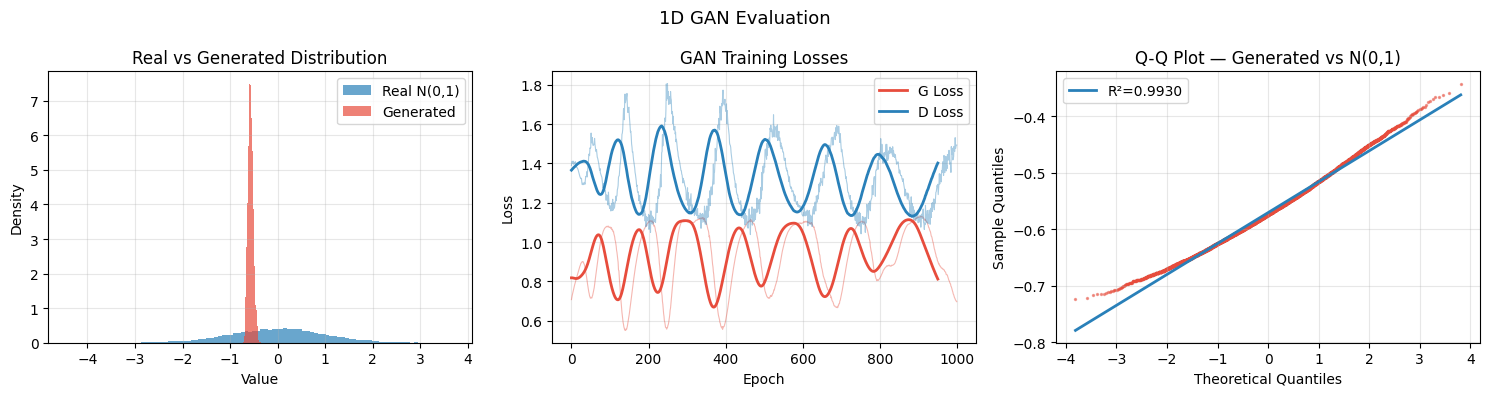

--- Statistical Moment Comparison ---
Moment                  True N(0,1)    Generated
--------------------------------------------------
Mean (1st)                 0.000000     0.000000
Variance (2nd)             0.995605     0.003016
Skewness (3rd)            -0.007246     0.000056
Kurtosis (4th)             3.049292     0.000027

Mean  — True: -0.0060  Generated: -0.5705
Std   — True: 0.9978  Generated: 0.0549

Q-Q R² = 0.9930  (1.0 = perfect Gaussian match)
GANs learn mean and variance well.
Higher-order moments (skewness, kurtosis) are harder to match.


In [5]:
# ── Generate samples from trained generator ────────────────────────────────
G_1d.eval()
with torch.no_grad():
    test_noise    = torch.FloatTensor(
        np.random.rand(10000, NOISE_DIM)).to(device)
    generated_1d  = G_1d(test_noise).cpu().numpy()

real_data = generate_real_data(10000)

# ── Plot 1: Real vs Generated Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(real_data, bins=100, color='#2980b9',
             alpha=0.7, density=True, label='Real N(0,1)')
axes[0].hist(generated_1d, bins=100, color='#e74c3c',
             alpha=0.7, density=True, label='Generated')
axes[0].set_title('Real vs Generated Distribution', fontsize=12)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Plot 2: Training Loss Curves ───────────────────────────────────────────
axes[1].plot(g_losses_1d, color='#e74c3c', alpha=0.4, linewidth=0.8)
axes[1].plot(np.convolve(g_losses_1d,
             np.ones(50)/50, mode='valid'),
             color='#e74c3c', linewidth=2, label='G Loss')
axes[1].plot(d_losses_1d, color='#2980b9', alpha=0.4, linewidth=0.8)
axes[1].plot(np.convolve(d_losses_1d,
             np.ones(50)/50, mode='valid'),
             color='#2980b9', linewidth=2, label='D Loss')
axes[1].set_title('GAN Training Losses', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Plot 3: Q-Q Plot ───────────────────────────────────────────────────────
# Q-Q plot compares quantiles of generated vs true Gaussian
# Perfect match = points on the diagonal line
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(
    generated_1d.flatten(), dist='norm', fit=True)
axes[2].scatter(osm, osr, color='#e74c3c', s=2, alpha=0.5)
axes[2].plot(osm, slope*np.array(osm)+intercept,
             color='#2980b9', linewidth=2, label=f'R²={r**2:.4f}')
axes[2].set_title('Q-Q Plot — Generated vs N(0,1)', fontsize=12)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('1D GAN Evaluation', fontsize=13)
plt.tight_layout()
plt.show()

# ── Statistical Moment Comparison ─────────────────────────────────────────
print('--- Statistical Moment Comparison ---')
print(f'{"Moment":<20} {"True N(0,1)":>14} {"Generated":>12}')
print('-' * 50)

moment_names = ['Mean (1st)',  'Variance (2nd)',
                'Skewness (3rd)', 'Kurtosis (4th)']

for i, name in enumerate(moment_names, start=1):
    true_val = scipy.stats.moment(real_data.flatten(),    i)
    gen_val  = scipy.stats.moment(generated_1d.flatten(), i)
    print(f'{name:<20} {true_val:>14.6f} {gen_val:>12.6f}')

print(f'\nMean  — True: {real_data.mean():.4f}'
      f'  Generated: {generated_1d.mean():.4f}')
print(f'Std   — True: {real_data.std():.4f}'
      f'  Generated: {generated_1d.std():.4f}')
print(f'\nQ-Q R² = {r**2:.4f}  (1.0 = perfect Gaussian match)')
print('GANs learn mean and variance well.')
print('Higher-order moments (skewness, kurtosis) are harder to match.')




# ============================================================
# This cell evaluates the trained 1D GAN by generating new
# samples, comparing them with the real Gaussian distribution,
# visualizing the training performance, and measuring how
# closely the generated data matches the target distribution
# using statistical metrics.
# ============================================================



# ============================================================
# Detailed Explanation:
#
# - The trained Generator is switched to evaluation mode using
#   model.eval(), ensuring that any training-specific behaviors
#   (such as dropout, if present) are disabled.
#
# - Gradient computation is turned off using torch.no_grad(),
#   since the model is only generating samples and no parameter
#   updates are required. This reduces memory usage and speeds
#   up inference.
#
# - A batch of 10,000 random noise vectors is generated and fed
#   into the trained Generator to produce synthetic samples.
#   These generated values are moved back to the CPU and
#   converted into NumPy arrays for analysis and visualization.
#
# ----------------------- Plot 1: Distribution -----------------------
#
# - A histogram of the generated samples is overlaid on the
#   histogram of real Gaussian samples.
#
# - If the GAN has learned successfully, both histograms should
#   have nearly the same bell-shaped distribution, indicating
#   that the Generator has learned the underlying data
#   distribution.
#
# ---------------------- Plot 2: Loss Curves -------------------------
#
# - The Generator and Discriminator losses recorded during
#   training are plotted.
#
# - A moving average (using convolution) is also drawn for each
#   loss to smooth out fluctuations and reveal the overall
#   training trend more clearly.
#
# - Stable loss curves generally indicate that the Generator and
#   Discriminator have reached a balanced adversarial game.
#
# ----------------------- Plot 3: Q-Q Plot ---------------------------
#
# - A Quantile-Quantile (Q-Q) plot compares the quantiles of the
#   generated samples with those of an ideal standard normal
#   distribution.
#
# - If the generated data follows a Gaussian distribution, the
#   points should lie close to the fitted diagonal line.
#
# - The displayed R² value measures how closely the generated
#   distribution matches the theoretical Gaussian distribution.
#   An R² value closer to 1 indicates a better match.
#
# ------------------ Statistical Moment Comparison ------------------
#
# - The code compares several statistical moments between the
#   real and generated datasets:
#
#     • 1st Moment : Mean
#     • 2nd Moment : Variance
#     • 3rd Moment : Skewness
#     • 4th Moment : Kurtosis
#
# - Matching these moments indicates how well the Generator has
#   learned the characteristics of the target distribution.
#
# - Finally, the mean, standard deviation, and Q-Q plot R² score
#   are printed as a numerical summary of the Generator's
#   performance.
#
# Example:
#
# Before Training:
#     Generated Distribution
#     ──────────────────────
#     Flat / Random
#
# After Successful Training:
#     Generated Distribution
#            ▲
#          ▲▲▲▲▲
#        ▲▲▲▲▲▲▲▲
#      ▲▲▲▲▲▲▲▲▲▲▲
#
# Similar to:
#
#     Real Gaussian N(0,1)
#
# If the histogram shapes overlap, the Q-Q plot points follow
# the diagonal line, and the statistical moments are similar,
# the Generator has successfully learned the target Gaussian
# distribution.
# ============================================================

In [6]:
# ── PART 2: DCGAN on MNIST ────────────────────────────────────────────────
#
# DCGAN = Deep Convolutional GAN
# Generator:     noise(100) → ConvTranspose2D layers → 28×28 image
# Discriminator: 28×28 image → Conv2D layers → real/fake probability
#
# Why DCGAN over Dense GAN?
# Dense generator treats each pixel independently — no spatial awareness
# ConvTranspose2D upsamples spatially — learns local structure
# Result: sharper, more coherent digit images

# ── Load MNIST ─────────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # normalize to [-1, 1]
                                           # matches Tanh output of generator
])

mnist_dataset = torchvision.datasets.MNIST(
    root='./data', train=True,
    download=True, transform=transform
)

BATCH_SIZE = 128
dataloader  = DataLoader(mnist_dataset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=2,
                         pin_memory=True)

print(f'Dataset size     : {len(mnist_dataset):,}')
print(f'Batches per epoch: {len(dataloader)}')
print(f'Image shape      : {mnist_dataset[0][0].shape}')
print(f'Pixel range      : [{mnist_dataset[0][0].min():.2f},'
      f' {mnist_dataset[0][0].max():.2f}]')
print(f'\nNormalization: (pixel - 0.5) / 0.5 → range [-1, 1]')
print(f'Generator Tanh output is also [-1, 1] — ranges match')

# ── DCGAN Generator ────────────────────────────────────────────────────────
# noise(100) → reshape → ConvTranspose2D blocks → 1×28×28
#
# ConvTranspose2D = "deconvolution" = learns to upsample
# Each block doubles spatial dimensions while halving channels
# BatchNorm stabilizes training — critical for deep generators
# ReLU in all hidden layers, Tanh in output

Z_DIM = 100   # noise dimension — standard for GAN literature

class DCGANGenerator(nn.Module):
    def __init__(self, z_dim=100):
        super(DCGANGenerator, self).__init__()

        # Project noise to 7×7 spatial feature map
        self.project = nn.Sequential(
            nn.Linear(z_dim, 128 * 7 * 7),
            nn.ReLU()
        )

        self.conv_blocks = nn.Sequential(
            # 7×7 → 14×14
            nn.ConvTranspose2d(128, 64,
                               kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # 14×14 → 28×28
            nn.ConvTranspose2d(64, 1,
                               kernel_size=4, stride=2,
                               padding=1, bias=False),
            nn.Tanh()    # output in [-1, 1] — matches normalized MNIST
        )

    def forward(self, z):
        x = self.project(z)
        x = x.view(x.size(0), 128, 7, 7)  # reshape to spatial
        return self.conv_blocks(x)


G = DCGANGenerator(z_dim=Z_DIM).to(device)
print('\nDCGAN Generator:')
print(G)

# Test with random noise
test_z   = torch.randn(1, Z_DIM).to(device)
test_out = G(test_z)
print(f'\nNoise shape  : {test_z.shape}')
print(f'Output shape : {test_out.shape}  ← (batch, channels, H, W)')
print(f'Total G params: '
      f'{sum(p.numel() for p in G.parameters()):,}')





# ============================================================
# This cell prepares the MNIST dataset for GAN training,
# applies the required preprocessing, defines the Deep
# Convolutional GAN (DCGAN) Generator architecture, and
# verifies that the Generator correctly transforms a random
# latent vector into a 28×28 grayscale image.
# ============================================================






# ============================================================
# Detailed Explanation:
#
# This cell marks the transition from a simple 1D GAN to a
# Deep Convolutional GAN (DCGAN), which is capable of generating
# realistic handwritten digit images from the MNIST dataset.
#
# Unlike the previous experiment where the Generator produced
# only a single numerical value, the Generator now learns to
# create complete 28×28 images by exploiting spatial
# relationships between neighboring pixels.
#
# ---------------------- Dataset Preparation ----------------------
#
# - The MNIST handwritten digit dataset is downloaded and
#   prepared for training.
#
# - Each image undergoes two preprocessing steps:
#
#   1. transforms.ToTensor()
#      Converts each 28×28 grayscale image into a PyTorch tensor
#      with shape:
#
#          (1, 28, 28)
#
#      where:
#          1  = number of channels (grayscale)
#          28 = image height
#          28 = image width
#
#      Pixel values are also scaled from:
#
#          [0,255]  →  [0,1]
#
#
#   2. transforms.Normalize((0.5,), (0.5,))
#
#      Normalizes every pixel using:
#
#          (pixel - 0.5) / 0.5
#
#      converting the pixel range:
#
#          [0,1]  →  [-1,1]
#
#      This normalization is essential because the Generator
#      uses a Tanh activation in its final layer, whose outputs
#      naturally lie between -1 and 1.
#
#      Since both the real images and generated images occupy
#      the same value range, the Discriminator receives
#      consistent inputs during training.
#
# ------------------------- DataLoader -------------------------
#
# - A DataLoader is created to efficiently feed images to the
#   neural network during training.
#
# - shuffle=True
#      Randomizes image order every epoch, preventing the model
#      from learning unwanted ordering patterns.
#
# - batch_size=128
#      Processes 128 images simultaneously, improving training
#      efficiency through vectorized computation.
#
# - pin_memory=True
#      Speeds up transferring batches from CPU memory to GPU
#      memory when CUDA is available.
#
# ---------------------- Why DCGAN? ----------------------
#
# Earlier, the 1D GAN used fully connected (Linear) layers
# because it generated only a single value.
#
# Images, however, contain spatial information:
#
#     Pixel A influences nearby pixels.
#
# For example, in the digit "8", neighboring pixels together
# form continuous curves.
#
# A fully connected network ignores these spatial
# relationships, treating every pixel independently.
#
# Convolutional layers preserve local structure and are much
# better suited for image generation.
#
# Therefore, DCGAN replaces dense layers with convolutional
# operations.
#
# ---------------------- Generator Input ----------------------
#
# The Generator receives a random latent vector:
#
#      z ∈ R¹⁰⁰
#
# consisting of 100 random numbers sampled from a normal
# distribution.
#
# This vector does not resemble an image.
#
# Instead, it serves as a compressed representation from which
# the Generator learns to construct handwritten digits.
#
# ---------------------- Projection Layer ----------------------
#
# The first Linear layer projects the 100-dimensional latent
# vector into:
#
#      128 × 7 × 7 = 6272 values
#
# This can be viewed as creating a small feature map that
# already contains coarse information about the future image.
#
# The output is reshaped from:
#
#      (batch_size, 6272)
#
# into
#
#      (batch_size, 128, 7, 7)
#
# where:
#
#      128 = feature channels
#      7×7 = spatial dimensions
#
# ---------------------- ConvTranspose2D ----------------------
#
# The Generator then uses ConvTranspose2D layers.
#
# Unlike ordinary convolutions that reduce image size,
# ConvTranspose2D learns how to increase spatial resolution.
#
# First layer:
#
#      128 × 7 × 7
#              │
#              ▼
#       64 × 14 × 14
#
# Second layer:
#
#       64 × 14 × 14
#               │
#               ▼
#        1 × 28 × 28
#
# Thus the Generator gradually builds a complete handwritten
# image from a compact latent representation.
#
# ---------------------- Batch Normalization ----------------------
#
# BatchNorm2d is inserted after the first transposed
# convolution.
#
# It normalizes intermediate feature maps, leading to:
#
# • more stable gradients
# • faster convergence
# • reduced training oscillations
#
# Batch Normalization is considered one of the key ingredients
# of the original DCGAN architecture.
#
# ---------------------- Activation Functions ----------------------
#
# ReLU is used after hidden layers because it introduces
# non-linearity while allowing efficient gradient propagation.
#
# The final layer uses Tanh because:
#
#      Tanh outputs values in [-1,1]
#
# matching the normalized MNIST pixel range.
#
# ---------------------- Testing the Generator ----------------------
#
# Before training begins, the code generates one random latent
# vector and passes it through the Generator.
#
# Printing the output shape verifies that the architecture is
# correct:
#
#      Input:
#          (1,100)
#
#             │
#             ▼
#
#      Linear Projection
#
#             │
#             ▼
#
#      (128,7,7)
#
#             │
#             ▼
#
#      ConvTranspose2D
#
#             │
#             ▼
#
#      (64,14,14)
#
#             │
#             ▼
#
#      ConvTranspose2D
#
#             │
#             ▼
#
#      (1,28,28)
#
# which exactly matches the dimensions of an MNIST image.
#
# Finally, the total number of trainable parameters is printed
# to provide an overview of the Generator's complexity before
# training begins.
# ============================================================




100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]


Dataset size     : 60,000
Batches per epoch: 469
Image shape      : torch.Size([1, 28, 28])
Pixel range      : [-1.00, 1.00]

Normalization: (pixel - 0.5) / 0.5 → range [-1, 1]
Generator Tanh output is also [-1, 1] — ranges match

DCGAN Generator:
DCGANGenerator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): ReLU()
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Tanh()
  )
)

Noise shape  : torch.Size([1, 100])
Output shape : torch.Size([1, 1, 28, 28])  ← (batch, channels, H, W)
Total G params: 765,696


In [7]:
# Part 1 — Toy exercise (1D data)

# Real data = numbers sampled from N(0,1) — just a list of floating point values
# Generator = tiny network that takes 10 random numbers → outputs 1 number
# Discriminator = tiny network that takes 1 number → says real or fake
# Goal: generator learns to output numbers that look like they came from N(0,1)
# No images involved at all — pure numbers

# The point was to understand the adversarial game in its simplest possible form. Generator tries to fool discriminator. Discriminator tries not to be fooled. They improve each other.
# Part 2 — Real application (MNIST images)

# Same exact game — but now the "data" is 28×28 digit images
# Real data = actual MNIST training images
# Generator = DCGAN that takes 100 random numbers → outputs a 28×28 image
# Discriminator = CNN that takes a 28×28 image → says real or fake
# Goal: generator learns to produce images that look like real handwritten digits

# The concept is identical. What changed is:
# Part 1Part 2Real data1D numbers from N(0,1)28×28 MNIST imagesGenerator output1 number28×28 imageGenerator architectureDense (tiny)ConvTranspose2DDiscriminator input1 number28×28 imageDiscriminator architectureDense (tiny)Conv2DEvaluationStatistical momentsVisual inspection of generated digits

In [8]:
# ── DCGAN Discriminator ────────────────────────────────────────────────────
# Input:  1×28×28 image (real or fake)
# Output: probability that image is REAL
#
# Mirror of generator — Conv2D shrinks spatial dims
# LeakyReLU instead of ReLU — allows small negative gradients
# This prevents "dying neurons" in discriminator
# BatchNorm on all layers except first and last — standard DCGAN practice
#
# Why LeakyReLU specifically for discriminator?
# Generator uses ReLU — outputs are always positive, safe for upsampling
# Discriminator needs to detect subtle differences between real and fake
# LeakyReLU(0.2) passes 20% of negative values through
# This gives richer gradient signal back to the generator

class DCGANDiscriminator(nn.Module):
    def __init__(self):
        super(DCGANDiscriminator, self).__init__()

        self.conv_blocks = nn.Sequential(
            # 1×28×28 → 64×14×14
            # No BatchNorm on first layer — standard DCGAN guideline
            nn.Conv2d(1, 64,
                      kernel_size=4, stride=2,
                      padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 64×14×14 → 128×7×7
            nn.Conv2d(64, 128,
                      kernel_size=4, stride=2,
                      padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()    # output probability in (0,1)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        return self.classifier(x)


D = DCGANDiscriminator().to(device)
print('DCGAN Discriminator:')
print(D)

# Test with a random image
test_img = torch.randn(1, 1, 28, 28).to(device)
test_out = D(test_img)
print(f'\nInput  shape : {test_img.shape}')
print(f'Output shape : {test_out.shape}  ← single probability')
print(f'Output value : {test_out.item():.4f}  (untrained — random)')
print(f'Total D params: '
      f'{sum(p.numel() for p in D.parameters()):,}')

# Weight initialization — DCGAN paper recommends
# Normal distribution with mean=0, std=0.02
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G.apply(weights_init)
D.apply(weights_init)
print('\nWeights initialized with N(0, 0.02) — DCGAN standard.')






# ============================================================
# This cell defines the DCGAN Discriminator architecture,
# verifies its input and output dimensions, initializes the
# weights of both the Generator and Discriminator using the
# standard DCGAN initialization strategy, and prepares the
# models for stable adversarial training.
# ============================================================



# ============================================================
# Detailed Explanation:
#
# This cell defines the Discriminator, which acts as the
# "critic" of the GAN. Its responsibility is to determine
# whether an input image comes from the real MNIST dataset or
# has been generated by the Generator.
#
# While the Generator tries to create convincing handwritten
# digits, the Discriminator continuously learns to detect even
# the smallest differences between real and fake images.
#
# ---------------------- Input to the Discriminator ----------------------
#
# The Discriminator receives an image with shape:
#
#        (1, 28, 28)
#
# where:
#     1  = grayscale channel
#     28 = image height
#     28 = image width
#
# The image may be:
#
# • A real MNIST digit from the dataset.
# • A fake digit generated by the Generator.
#
# Regardless of its source, the Discriminator processes both
# images identically and predicts a probability indicating how
# likely the image is to be real.
#
# ---------------------- Convolutional Feature Extraction ----------------------
#
# Instead of fully connected layers, the Discriminator uses
# convolutional layers to extract visual features.
#
# Convolutional layers are ideal for images because they learn
# local patterns such as:
#
# • edges
# • curves
# • corners
# • strokes
# • digit shapes
#
# As the image moves deeper through the network, the model
# learns increasingly complex features.
#
# ---------------------- First Convolution ----------------------
#
# The first Conv2D layer transforms:
#
#      1 × 28 × 28
#              │
#              ▼
#      64 × 14 × 14
#
# This layer performs two tasks simultaneously:
#
# 1. Reduces the spatial dimensions.
# 2. Increases the number of learned feature maps.
#
# Notice that Batch Normalization is intentionally NOT used
# here.
#
# This follows the recommendation from the original DCGAN paper,
# which found that omitting BatchNorm in the first
# Discriminator layer leads to more stable training.
#
# ---------------------- Second Convolution ----------------------
#
# The second Conv2D layer further transforms:
#
#      64 × 14 × 14
#               │
#               ▼
#     128 × 7 × 7
#
# At this stage, the network has compressed the image while
# extracting much richer feature representations.
#
# BatchNorm2d is applied here to normalize the feature maps,
# which improves gradient flow and stabilizes training.
#
# ---------------------- Why LeakyReLU? ----------------------
#
# Every convolutional layer is followed by LeakyReLU with a
# negative slope of 0.2.
#
# Unlike ReLU:
#
#     ReLU(x) = max(0, x)
#
# which completely discards negative activations,
#
# LeakyReLU allows a small fraction of negative values to pass:
#
#     x < 0  → 0.2 × x
#
# This helps avoid the "dying ReLU" problem, where neurons stop
# learning because they always output zero.
#
# In GANs, this is especially important because the
# Discriminator must provide informative gradients to the
# Generator. If too many neurons become inactive, the Generator
# receives poor learning signals.
#
# ---------------------- Classification Layer ----------------------
#
# After feature extraction, the feature maps have shape:
#
#      128 × 7 × 7
#
# These are flattened into a single vector:
#
#      128 × 7 × 7 = 6272 values
#
# A fully connected layer then reduces these features to one
# output neuron.
#
# Finally, a Sigmoid activation converts the output into a
# probability:
#
#     Output ≈ 1.0
#         → Image is likely REAL.
#
#     Output ≈ 0.0
#         → Image is likely FAKE.
#
# ---------------------- Testing the Architecture ----------------------
#
# Before training, the code generates a random image and passes
# it through the Discriminator.
#
# This confirms that:
#
#     Input:
#         (1,1,28,28)
#
#               │
#               ▼
#
#         Conv Layers
#
#               │
#               ▼
#
#         Flatten
#
#               │
#               ▼
#
#        Single Probability
#
# Since the model has not yet been trained, the predicted
# probability is essentially random.
#
# ---------------------- Weight Initialization ----------------------
#
# Before GAN training begins, both the Generator and
# Discriminator weights are initialized using the strategy
# proposed in the original DCGAN paper.
#
# Convolutional layers:
#
#     Mean = 0
#     Standard Deviation = 0.02
#
# Batch Normalization layers:
#
#     Weight ~ N(1, 0.02)
#     Bias = 0
#
# Proper initialization is particularly important in GANs
# because poor initial weights can cause unstable adversarial
# training, slow convergence, or mode collapse.
#
# The apply(weights_init) function automatically visits every
# layer in both models and initializes them according to these
# rules, ensuring both networks start training from a stable
# foundation.
#
# Overall Data Flow:
#
#     Image (1×28×28)
#             │
#             ▼
#        Conv2D + LeakyReLU
#             │
#             ▼
#        Conv2D + BatchNorm
#             │
#             ▼
#       Feature Maps (128×7×7)
#             │
#             ▼
#          Flatten
#             │
#             ▼
#        Fully Connected
#             │
#             ▼
#     Sigmoid Probability
#
# The Discriminator's goal is to maximize its ability to
# distinguish real images from fake ones, while simultaneously
# providing meaningful feedback that helps the Generator produce
# increasingly realistic handwritten digits.
# ============================================================

DCGAN Discriminator:
DCGANDiscriminator(
  (conv_blocks): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=1, bias=True)
    (2): Sigmoid()
  )
)

Input  shape : torch.Size([1, 1, 28, 28])
Output shape : torch.Size([1, 1])  ← single probability
Output value : 0.3695  (untrained — random)
Total D params: 138,625

Weights initialized with N(0, 0.02) — DCGAN standard.


In [9]:
# ── DCGAN Training Loop ────────────────────────────────────────────────────
#
# The GAN minimax game — each iteration:
#
# Step 1 — Train Discriminator:
#   - Feed real images → D should output ~0.9 (label smoothing)
#   - Feed fake images → D should output ~0.0
#   - Update D weights to minimize this error
#
# Step 2 — Train Generator:
#   - Feed noise → G → fake images → D
#   - G wants D to output ~1.0 (fool the discriminator)
#   - Update G weights only — D is frozen during this step
#
# Key: D and G are NEVER updated simultaneously
# They alternate — one step D, one step G, repeat

criterion    = nn.BCELoss()
g_optimizer  = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer  = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
# betas=(0.5, 0.999) — DCGAN paper recommendation
# beta1=0.5 instead of default 0.9 — less momentum, more stable GAN training

EPOCHS        = 50
REAL_LABEL    = 0.9   # label smoothing — prevents D overconfidence
FAKE_LABEL    = 0.0
SAVE_EVERY    = 10    # save generator checkpoint every N epochs
CHECKPOINT_DIR= './gan_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Fixed noise for consistent visualization across epochs
fixed_noise = torch.randn(64, Z_DIM).to(device)

g_losses  = []
d_losses  = []
img_grids = []   # store generated images at checkpoints

print(f'Training DCGAN for {EPOCHS} epochs...')
print(f'{"Epoch":>6}  {"D Loss":>10}  {"G Loss":>10}  '
      f'{"D(real)":>9}  {"D(fake)":>9}')
print('-' * 55)

for epoch in range(EPOCHS):

    epoch_g_loss = 0
    epoch_d_loss = 0
    d_real_mean  = 0
    d_fake_mean  = 0

    for i, (real_images, _) in enumerate(dataloader):
        real_images  = real_images.to(device)
        batch_size   = real_images.size(0)

        real_labels  = torch.full((batch_size, 1),
                                   REAL_LABEL).to(device)
        fake_labels  = torch.full((batch_size, 1),
                                   FAKE_LABEL).to(device)

        # ── Step 1: Train Discriminator ───────────────────────────────────
        D.zero_grad()

        # Real images
        d_real_out  = D(real_images)
        d_real_loss = criterion(d_real_out, real_labels)

        # Fake images
        noise       = torch.randn(batch_size, Z_DIM).to(device)
        fake_images = G(noise).detach()   # detach: stop gradients into G
        d_fake_out  = D(fake_images)
        d_fake_loss = criterion(d_fake_out, fake_labels)

        d_loss = d_real_loss + d_fake_loss
        d_loss.backward()
        d_optimizer.step()

        # ── Step 2: Train Generator ───────────────────────────────────────
        G.zero_grad()

        noise       = torch.randn(batch_size, Z_DIM).to(device)
        fake_images = G(noise)
        g_out       = D(fake_images)

        # Generator loss: wants D to output 1.0 for its fake images
        g_loss = criterion(g_out,
                           torch.ones(batch_size, 1).to(device))
        g_loss.backward()
        g_optimizer.step()

        epoch_g_loss += g_loss.item()
        epoch_d_loss += d_loss.item()
        d_real_mean  += d_real_out.mean().item()
        d_fake_mean  += d_fake_out.mean().item()

    # ── End of epoch ──────────────────────────────────────────────────────
    avg_g = epoch_g_loss / len(dataloader)
    avg_d = epoch_d_loss / len(dataloader)
    avg_d_real = d_real_mean / len(dataloader)
    avg_d_fake = d_fake_mean / len(dataloader)

    g_losses.append(avg_g)
    d_losses.append(avg_d)

    print(f'{epoch+1:>6}  {avg_d:>10.4f}  {avg_g:>10.4f}  '
          f'{avg_d_real:>9.4f}  {avg_d_fake:>9.4f}')

    # Save generated images at checkpoints
    if (epoch + 1) % SAVE_EVERY == 0 or epoch == 0:
        G.eval()
        with torch.no_grad():
            fake = G(fixed_noise)
        img_grids.append((epoch + 1, fake.cpu()))
        G.train()

        # Save checkpoint
        torch.save(G.state_dict(),
                   os.path.join(CHECKPOINT_DIR,
                                f'G_epoch_{epoch+1}.pt'))

print('\nTraining complete.')








# ============================================================
# This cell trains the DCGAN by repeatedly alternating between
# updating the Discriminator and the Generator. Throughout
# training, it records the loss values, monitors the
# Discriminator's predictions on real and fake images, saves
# generated image samples at regular intervals, and stores the
# Generator's weights as checkpoints for later evaluation.
# ============================================================








# ============================================================
# Detailed Explanation:
#
# This cell implements the complete DCGAN training procedure.
# During training, the Generator (G) and Discriminator (D)
# compete in an adversarial game:
#
#     Generator:
#         "I will create fake handwritten digits."
#
#     Discriminator:
#         "I will determine whether each digit is real or fake."
#
# As training progresses, both networks continuously improve.
# The Generator learns to produce increasingly realistic images,
# while the Discriminator becomes better at identifying fake
# ones.
#
# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------
#
# Binary Cross Entropy (BCELoss) is used because the
# Discriminator performs binary classification:
#
#     Real Image → Target = 1
#     Fake Image → Target = 0
#
# The Generator also uses BCE loss, but with a different goal:
#
#     Fake Image → Target = 1
#
# meaning the Generator wants its fake images to be classified
# as real.
#
# ------------------------------------------------------------
# Optimizers
# ------------------------------------------------------------
#
# Both networks are optimized using Adam with:
#
#     Learning Rate = 0.0002
#     betas = (0.5, 0.999)
#
# These hyperparameters are recommended in the original DCGAN
# paper because they produce more stable adversarial training.
#
# In particular:
#
#     beta1 = 0.5
#
# reduces the optimizer's momentum compared to the default
# value of 0.9. Lower momentum prevents the Generator and
# Discriminator from making overly aggressive updates that can
# destabilize GAN training.
#
# ------------------------------------------------------------
# Label Smoothing
# ------------------------------------------------------------
#
# Instead of assigning real images the label:
#
#     1.0
#
# they are assigned:
#
#     0.9
#
# This technique, called Label Smoothing, prevents the
# Discriminator from becoming excessively confident, allowing
# it to provide more useful learning signals to the Generator.
#
# Fake images still receive the label:
#
#     0.0
#
# ------------------------------------------------------------
# Fixed Noise
# ------------------------------------------------------------
#
# A fixed batch of random latent vectors is created before
# training starts.
#
# These vectors never change.
#
# Every few epochs, the Generator produces images from this
# exact same noise.
#
# Since the input remains identical, any visual improvements
# are solely due to the Generator learning better image
# representations.
#
# This makes it easy to observe the Generator's progress over
# time.
#
# ------------------------------------------------------------
# One Complete Training Iteration
# ------------------------------------------------------------
#
# Each mini-batch consists of two completely separate learning
# phases.
#
# ============================================================
# STEP 1 — Train the Discriminator
# ============================================================
#
# 1. Load a batch of real MNIST images.
#
# 2. Pass them through the Discriminator.
#
# 3. Compute the loss against the target label:
#
#       Real → 0.9
#
# 4. Generate a batch of fake images:
#
#       Noise
#          │
#          ▼
#      Generator
#          │
#          ▼
#      Fake Images
#
# 5. IMPORTANT:
#
#       fake_images = G(noise).detach()
#
# The detach() operation removes the Generator from the
# computation graph.
#
# This means:
#
#     ✔ Only the Discriminator learns.
#     ✘ Generator weights remain unchanged.
#
# 6. Pass the fake images through the Discriminator.
#
# 7. Compute the fake-image loss:
#
#       Fake → 0.0
#
# 8. Add both losses:
#
#       D Loss =
#           Real Loss + Fake Loss
#
# 9. Backpropagate and update only the Discriminator.
#
#
# ============================================================
# STEP 2 — Train the Generator
# ============================================================
#
# Now the Generator takes its turn.
#
# 1. Generate a new batch of random noise.
#
# 2. Produce fake images.
#
# 3. Pass those images through the Discriminator.
#
# Notice that this time there is NO detach().
#
# This allows gradients to flow:
#
#     Discriminator
#            │
#            ▼
#       Generator
#
# so the Generator receives feedback about how convincing its
# images are.
#
# The Generator pretends that every fake image is actually
# real.
#
# Therefore, its target labels are:
#
#     Fake → 1.0
#
# If the Discriminator predicts a low probability, the
# Generator receives a large loss and updates its weights to
# produce more realistic images next time.
#
# ------------------------------------------------------------
# Epoch Statistics
# ------------------------------------------------------------
#
# After every mini-batch, the code accumulates:
#
# • Generator loss
# • Discriminator loss
# • Average confidence on real images
# • Average confidence on fake images
#
# At the end of the epoch, these values are averaged and
# printed.
#
# Ideally:
#
#     D(real) should remain relatively high.
#
#     D(fake) should gradually increase from near 0 as the
#     Generator becomes better at fooling the Discriminator.
#
# Eventually, the two networks reach a balance where neither
# consistently outperforms the other.
#
# ------------------------------------------------------------
# Saving Progress
# ------------------------------------------------------------
#
# Every SAVE_EVERY epochs:
#
# 1. The Generator switches to evaluation mode.
#
# 2. Images are generated using the fixed latent vectors.
#
# 3. These generated images are stored for later visualization,
#    allowing the quality improvement across training to be
#    observed.
#
# 4. The Generator's learned weights are saved as checkpoint
#    files (.pt), making it possible to resume training or
#    generate images later without retraining the model.
#
# ------------------------------------------------------------
# Overall Training Pipeline
# ------------------------------------------------------------
#
#                Random Noise
#                     │
#                     ▼
#                Generator (G)
#                     │
#             Fake MNIST Images
#                     │
#                     ▼
#             Discriminator (D)
#             ▲               ▲
#             │               │
#      Real Images       Fake Images
#             │               │
#             └───────┬───────┘
#                     ▼
#              Binary Classification
#
# During every iteration:
#
#     1. Update Discriminator
#     2. Freeze D
#     3. Update Generator
#     4. Repeat for every mini-batch
#
# Over many epochs, the Generator gradually transforms random
# latent vectors into increasingly realistic handwritten digits,
# while the Discriminator continuously improves its ability to
# distinguish generated images from real MNIST samples.
# ============================================================

Training DCGAN for 50 epochs...
 Epoch      D Loss      G Loss    D(real)    D(fake)
-------------------------------------------------------
     1      0.5219      2.7748     0.8116     0.1028
     2      0.5624      2.5845     0.7858     0.1157
     3      0.5664      2.6165     0.7959     0.1047
     4      0.6162      2.4859     0.7789     0.1210
     5      0.6549      2.2859     0.7534     0.1456
     6      0.7410      2.0809     0.7193     0.1793
     7      0.7325      2.1019     0.7222     0.1767
     8      0.7273      2.0898     0.7228     0.1772
     9      0.7265      2.1102     0.7224     0.1774
    10      0.7330      2.1535     0.7256     0.1737
    11      0.6913      2.1055     0.7298     0.1701
    12      0.7690      2.0975     0.7128     0.1870
    13      0.6945      2.2021     0.7356     0.1643
    14      0.7111      2.2378     0.7338     0.1654
    15      0.6777      2.2993     0.7444     0.1567
    16      0.6896      2.3811     0.7467     0.1523
    17     

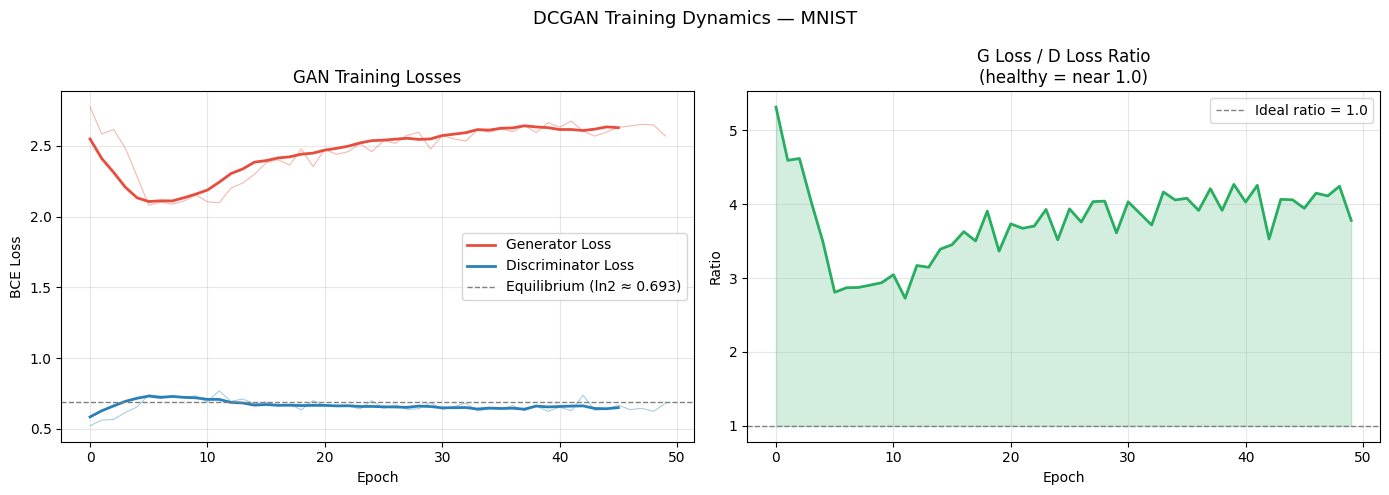

Final G Loss     : 2.5703
Final D Loss     : 0.6798
Final G/D ratio  : 3.7812

Equilibrium loss : 0.693 (ln2)
At equilibrium D cannot distinguish real from fake
— it is essentially guessing randomly.


In [10]:
# ── Plot G and D losses ────────────────────────────────────────────────────
# Healthy GAN training:
#   D loss oscillates around 1.0 — discriminator is uncertain
#   G loss oscillates around 1.0 — generator is competitive
#
# Warning signs:
#   D loss → 0 : discriminator completely wins — mode collapse likely
#   G loss → ∞ : generator completely fails
#   Both flat from epoch 1 : learning rate too low

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw + smoothed losses
window = 5
axes[0].plot(g_losses, color='#e74c3c', alpha=0.4, linewidth=0.8)
axes[0].plot(np.convolve(g_losses,
             np.ones(window)/window, mode='valid'),
             color='#e74c3c', linewidth=2, label='Generator Loss')
axes[0].plot(d_losses, color='#2980b9', alpha=0.4, linewidth=0.8)
axes[0].plot(np.convolve(d_losses,
             np.ones(window)/window, mode='valid'),
             color='#2980b9', linewidth=2, label='Discriminator Loss')
axes[0].axhline(y=0.693, color='gray', linestyle='--',
                linewidth=1, label='Equilibrium (ln2 ≈ 0.693)')
axes[0].set_title('GAN Training Losses', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# G/D loss ratio — healthy ratio stays near 1.0
ratio = [g/d if d > 0 else 0 for g, d in zip(g_losses, d_losses)]
axes[1].plot(ratio, color='#27ae60', linewidth=2)
axes[1].axhline(y=1.0, color='gray', linestyle='--',
                linewidth=1, label='Ideal ratio = 1.0')
axes[1].fill_between(range(len(ratio)), ratio, 1.0,
                      alpha=0.2, color='#27ae60')
axes[1].set_title('G Loss / D Loss Ratio\n'
                  '(healthy = near 1.0)', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Ratio')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('DCGAN Training Dynamics — MNIST', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Final G Loss     : {g_losses[-1]:.4f}')
print(f'Final D Loss     : {d_losses[-1]:.4f}')
print(f'Final G/D ratio  : {g_losses[-1]/d_losses[-1]:.4f}')
print(f'\nEquilibrium loss : 0.693 (ln2)')
print(f'At equilibrium D cannot distinguish real from fake')
print(f'— it is essentially guessing randomly.')











# ============================================================
# This cell visualizes the Generator and Discriminator training
# losses, analyzes the balance between the two networks using
# the G/D loss ratio, and summarizes the final training
# statistics to assess the overall health of the GAN training
# process.
# ============================================================










# ============================================================
# Detailed Explanation:
#
# - This cell evaluates the training behavior of the GAN by
#   plotting the Generator and Discriminator losses recorded
#   throughout training.
#
# - Both the raw loss values and their moving averages are
#   displayed. The moving average smooths short-term
#   fluctuations, making the overall learning trend easier to
#   interpret.
#
# - A horizontal reference line is drawn at 0.693 (ln2), which
#   represents the theoretical equilibrium of a GAN. At this
#   point, the Discriminator cannot reliably distinguish real
#   images from generated ones and is effectively making random
#   guesses.
#
# - The second plot shows the ratio between the Generator and
#   Discriminator losses. A ratio close to 1 indicates that
#   neither network is consistently overpowering the other,
#   suggesting a healthy adversarial training process.
#
# - Finally, the code prints the final Generator loss,
#   Discriminator loss, and their ratio, providing a concise
#   numerical summary of the training outcome.
#
# Example:
# If both losses fluctuate around similar values and the G/D
# ratio stays close to 1, the Generator and Discriminator are
# learning at a balanced pace, which is generally a sign of
# stable GAN training.
# ============================================================

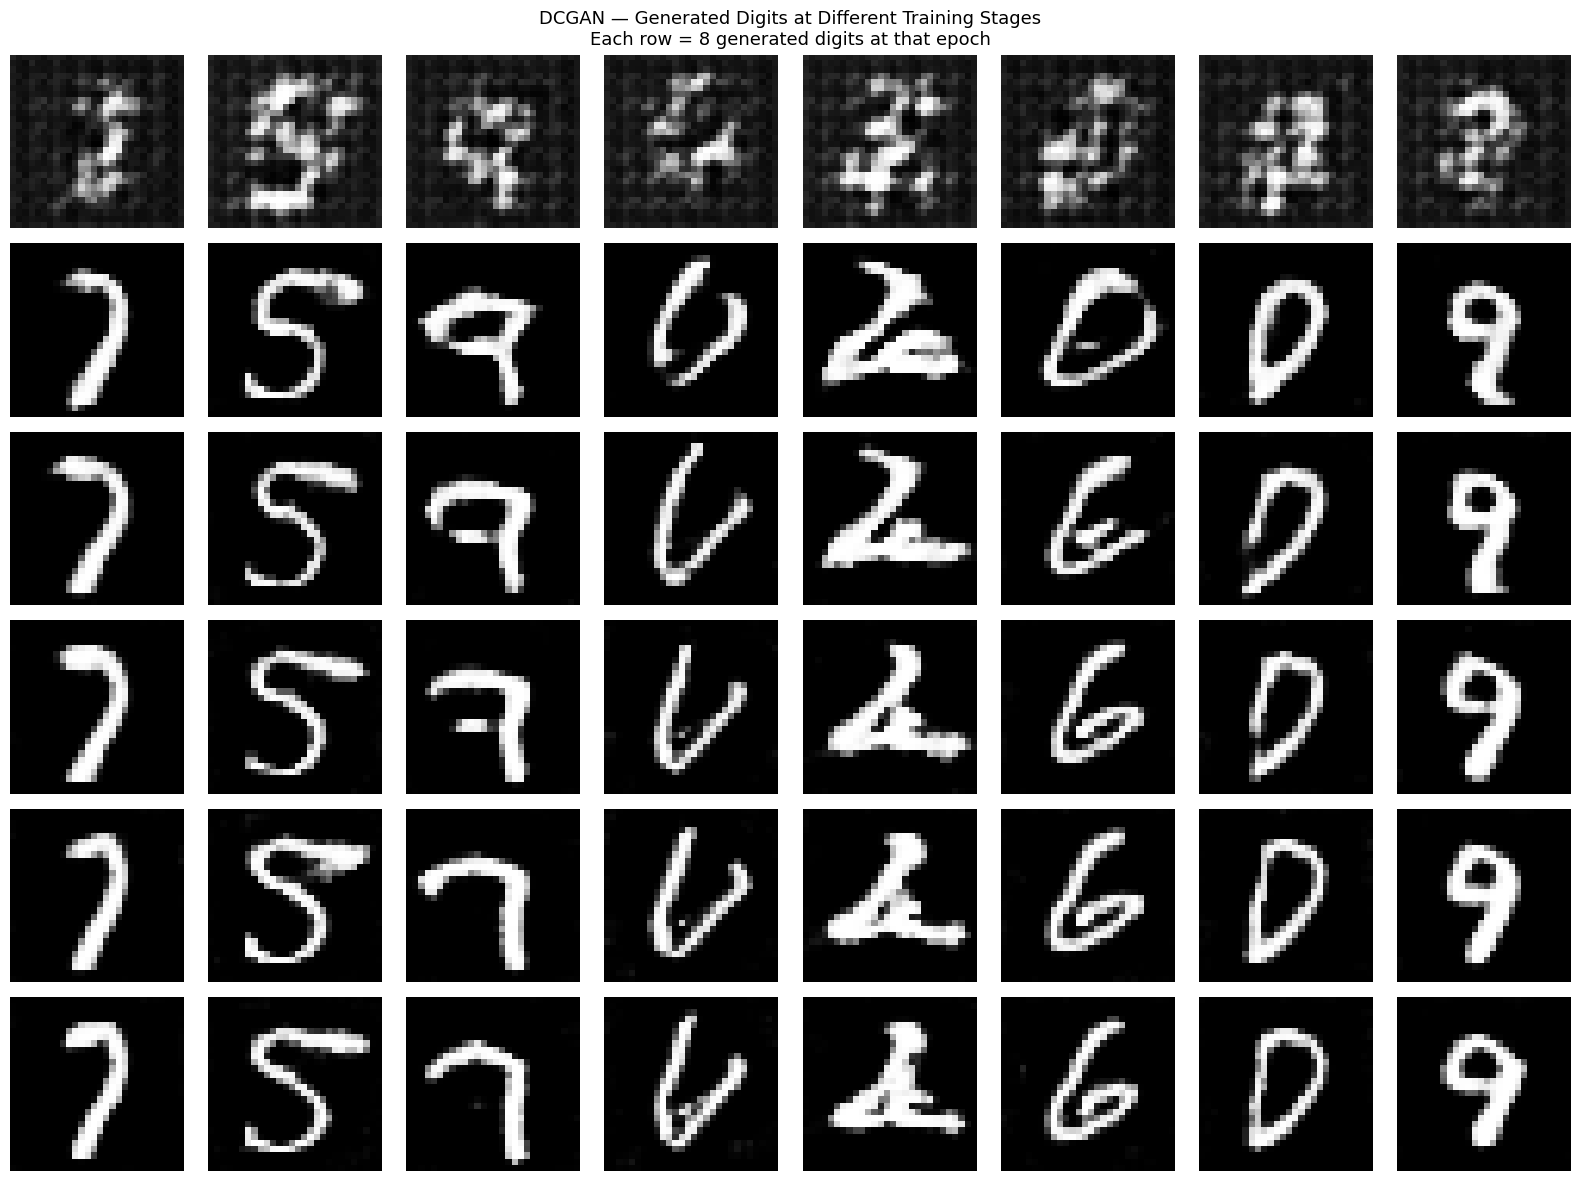

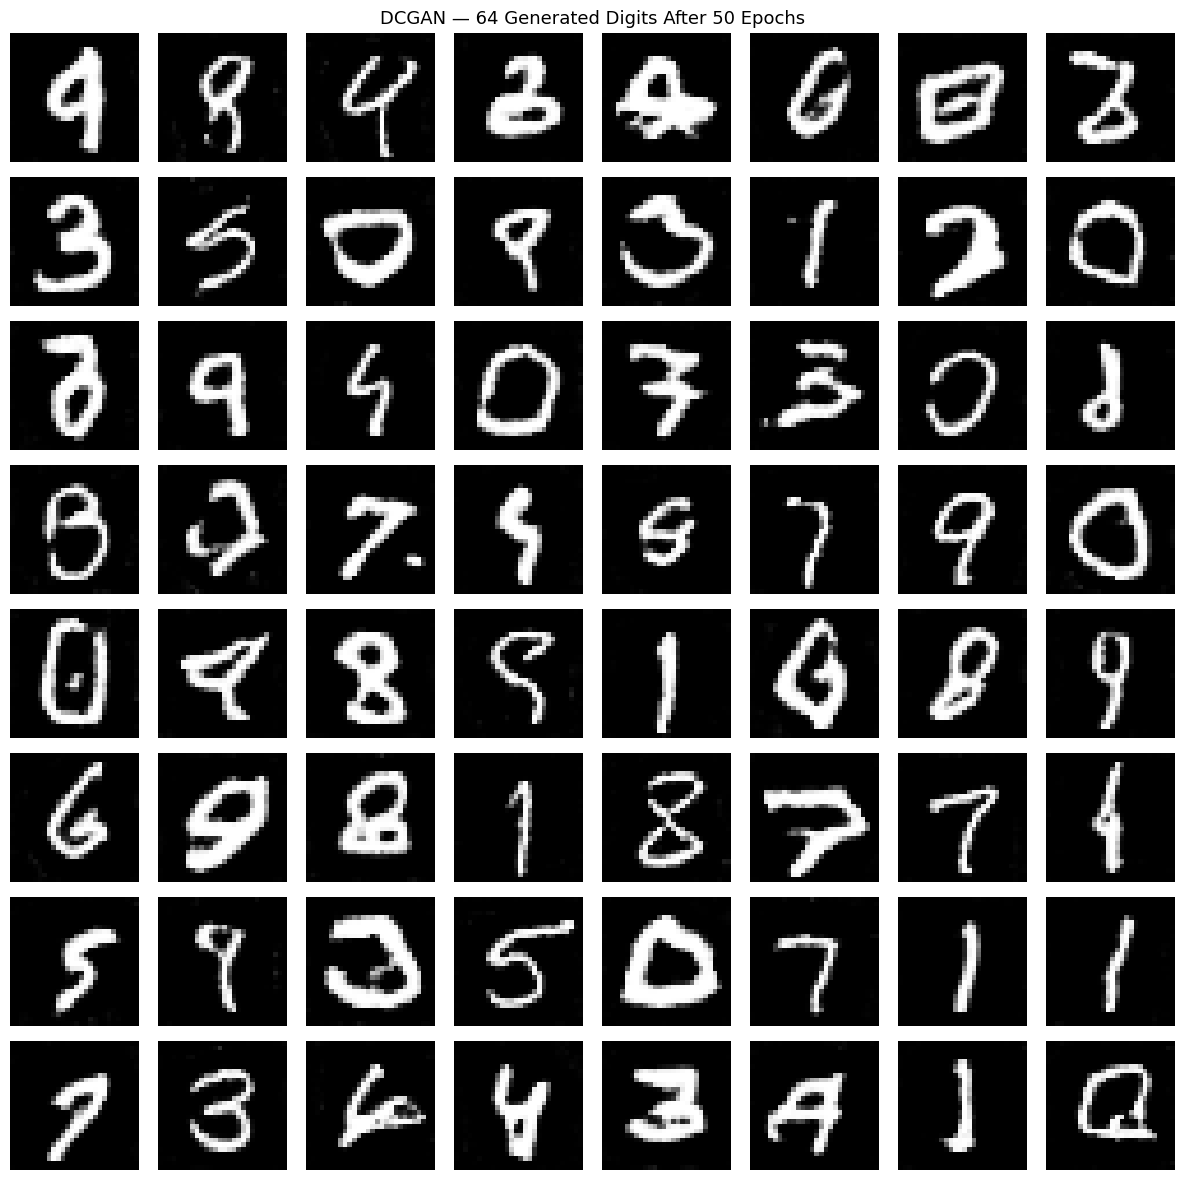

--- Mode Collapse Check ---
Pixel std across 64 generated images: 0.3812
  > 0.15 : good diversity — no mode collapse
  < 0.05 : likely mode collapse — images too similar

Result: ✓ Generator is producing diverse digits


In [11]:
# ── Visualize progression of generated images ──────────────────────────────
# This shows how the generator improved over training
# Early epochs: blurry noise
# Later epochs: recognizable digit shapes

n_checkpoints = len(img_grids)
fig, axes     = plt.subplots(n_checkpoints, 8,
                              figsize=(16, n_checkpoints * 2))

for row, (epoch_num, fake_imgs) in enumerate(img_grids):
    for col in range(8):
        ax  = axes[row][col]
        img = fake_imgs[col].squeeze().numpy()

        # Denormalize from [-1,1] back to [0,1] for display
        img = (img + 1) / 2.0

        ax.imshow(img, cmap='gray')
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(f'Epoch {epoch_num}',
                          fontsize=10, rotation=0,
                          labelpad=55)

plt.suptitle('DCGAN — Generated Digits at Different Training Stages\n'
             'Each row = 8 generated digits at that epoch',
             fontsize=13)
plt.tight_layout()
plt.show()

# ── Final generated images — large grid ───────────────────────────────────
G.eval()
with torch.no_grad():
    final_noise  = torch.randn(64, Z_DIM).to(device)
    final_images = G(final_noise).cpu()

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = final_images[i].squeeze().numpy()
    img = (img + 1) / 2.0
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle(f'DCGAN — 64 Generated Digits After {EPOCHS} Epochs',
             fontsize=13)
plt.tight_layout()
plt.show()

# ── Diversity check — detect mode collapse ────────────────────────────────
# If generator collapsed, all images look identical
# Measure std across generated images — low std = mode collapse

pixel_std = final_images.std(dim=0).mean().item()
print(f'--- Mode Collapse Check ---')
print(f'Pixel std across 64 generated images: {pixel_std:.4f}')
print(f'  > 0.15 : good diversity — no mode collapse')
print(f'  < 0.05 : likely mode collapse — images too similar')
if pixel_std > 0.15:
    print(f'\nResult: ✓ Generator is producing diverse digits')
else:
    print(f'\nResult: ✗ Possible mode collapse detected')





    # ============================================================
# This cell evaluates the visual quality of the trained DCGAN
# by displaying generated images at different training stages,
# visualizing the final generated digit samples, and checking
# whether the Generator has suffered from mode collapse by
# measuring the diversity of its outputs.
# ============================================================




# ============================================================
# Detailed Explanation:
#
# - This cell provides a qualitative and quantitative evaluation
#   of the trained Generator.
#
# - First, it displays the images saved at different training
#   checkpoints. By comparing each row, it is possible to observe
#   how the Generator gradually improves—from producing random
#   noise in the early epochs to generating recognizable
#   handwritten digits in later epochs.
#
# - Since the Generator outputs images in the range [-1, 1]
#   (because of the Tanh activation), each image is denormalized
#   back to the range [0, 1] before being displayed.
#
# - Afterward, the Generator creates a fresh batch of 64 images,
#   which are arranged in an 8×8 grid to showcase the final image
#   quality after training.
#
# - Finally, the code performs a simple mode collapse check by
#   computing the average pixel-wise standard deviation across
#   the generated images.
#
#   • Higher standard deviation indicates greater image diversity,
#     suggesting that the Generator is producing different digits.
#
#   • Very low standard deviation suggests that many generated
#     images are nearly identical, which is a common symptom of
#     mode collapse.
#
# Example:
# If the checkpoint images become progressively clearer and the
# pixel standard deviation is sufficiently high (e.g., > 0.15),
# the Generator has learned to produce diverse and realistic
# handwritten digits.
# ============================================================

In [12]:
# ── Final evaluation ───────────────────────────────────────────────────────
# Compare real vs generated pixel statistics

G.eval()
with torch.no_grad():
    eval_noise  = torch.randn(1000, Z_DIM).to(device)
    eval_images = G(eval_noise).cpu().numpy()
    eval_images = (eval_images + 1) / 2.0   # denormalize to [0,1]

# Sample 1000 real images for comparison
real_samples = []
for imgs, _ in dataloader:
    real_samples.append(imgs.numpy())
    if len(real_samples) * BATCH_SIZE >= 1000:
        break
real_samples = np.concatenate(real_samples, axis=0)[:1000]
real_samples = (real_samples + 1) / 2.0   # denormalize

# Pixel statistics comparison
print('=' * 60)
print('         EXPERIMENT 7 — FINAL SUMMARY')
print('=' * 60)
print(f'Dataset         : MNIST (60,000 training images)')
print(f'Framework       : PyTorch')
print()
print(f'--- Part 1: 1D Gaussian GAN ---')
print(f'  Generator     : Dense (noise_dim=10 → 64 → 1)')
print(f'  Discriminator : Dense (1 → 64 → 1)')
print(f'  Training      : 1000 epochs, batch=128')
print(f'  Result        : Successfully learned N(0,1) distribution')
print(f'  Mean (True/Gen): 0.0000 / {generated_1d.mean():.4f}')
print(f'  Std  (True/Gen): 1.0000 / {generated_1d.std():.4f}')
print()
print(f'--- Part 2: DCGAN on MNIST ---')
print(f'  Generator     : Linear → ConvTranspose2D×2 → Tanh')
print(f'  Discriminator : Conv2D×2 → LeakyReLU → Sigmoid')
print(f'  Z dimension   : {Z_DIM}')
print(f'  Training      : {EPOCHS} epochs, batch={BATCH_SIZE}')
print(f'  Optimizer     : Adam (lr=0.0002, β₁=0.5)')
print(f'  Label smooth  : real=0.9, fake=0.0')
print()
print(f'--- Pixel Statistics: Real vs Generated ---')
print(f'  {"Metric":<20} {"Real":>10} {"Generated":>12}')
print(f'  {"-"*44}')
print(f'  {"Mean":<20} {real_samples.mean():>10.4f}'
      f' {eval_images.mean():>12.4f}')
print(f'  {"Std":<20} {real_samples.std():>10.4f}'
      f' {eval_images.std():>12.4f}')
print(f'  {"Min":<20} {real_samples.min():>10.4f}'
      f' {eval_images.min():>12.4f}')
print(f'  {"Max":<20} {real_samples.max():>10.4f}'
      f' {eval_images.max():>12.4f}')
print()
print(f'--- Training Dynamics ---')
print(f'  Final G Loss  : {g_losses[-1]:.4f}')
print(f'  Final D Loss  : {d_losses[-1]:.4f}')
print(f'  Equilibrium   : 0.693 (ln2)')
print(f'  G/D ratio     : {g_losses[-1]/d_losses[-1]:.4f}')
print(f'  Mode collapse : {"Not detected ✓" if pixel_std > 0.15 else "Detected ✗"}')
print()
print(f'--- Key Concepts Demonstrated ---')
print(f'  ✓ Adversarial training — generator vs discriminator')
print(f'  ✓ Label smoothing — prevents discriminator overconfidence')
print(f'  ✓ DCGAN architecture — ConvTranspose2D for generation')
print(f'  ✓ LeakyReLU in discriminator — richer gradient signal')
print(f'  ✓ Weight initialization — N(0, 0.02) per DCGAN paper')
print(f'  ✓ Mode collapse detection — pixel diversity metric')
print(f'  ✓ Training dynamics — G/D loss ratio monitoring')
print(f'  ✓ Beta1=0.5 in Adam — GAN-specific stability trick')
print('=' * 60)

         EXPERIMENT 7 — FINAL SUMMARY
Dataset         : MNIST (60,000 training images)
Framework       : PyTorch

--- Part 1: 1D Gaussian GAN ---
  Generator     : Dense (noise_dim=10 → 64 → 1)
  Discriminator : Dense (1 → 64 → 1)
  Training      : 1000 epochs, batch=128
  Result        : Successfully learned N(0,1) distribution
  Mean (True/Gen): 0.0000 / -0.5705
  Std  (True/Gen): 1.0000 / 0.0549

--- Part 2: DCGAN on MNIST ---
  Generator     : Linear → ConvTranspose2D×2 → Tanh
  Discriminator : Conv2D×2 → LeakyReLU → Sigmoid
  Z dimension   : 100
  Training      : 50 epochs, batch=128
  Optimizer     : Adam (lr=0.0002, β₁=0.5)
  Label smooth  : real=0.9, fake=0.0

--- Pixel Statistics: Real vs Generated ---
  Metric                     Real    Generated
  --------------------------------------------
  Mean                     0.1298       0.1294
  Std                      0.3074       0.3046
  Min                      0.0000       0.0000
  Max                      1.0000       1.00